<a href="https://colab.research.google.com/github/Revathi0828/Deep_Learning/blob/main/Auto_encoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - loss: 0.2510 - val_loss: 0.1712
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1530 - val_loss: 0.1380
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.1334 - val_loss: 0.1270
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.1243 - val_loss: 0.1192
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.1183 - val_loss: 0.1141
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.1136 - val_loss: 0.1103
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 0.1103 - val_loss: 0.1081
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 0.1077 - val_loss: 0.1051
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.1055 - val_loss: 0.1033
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.1037 - val_loss: 0.1017
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


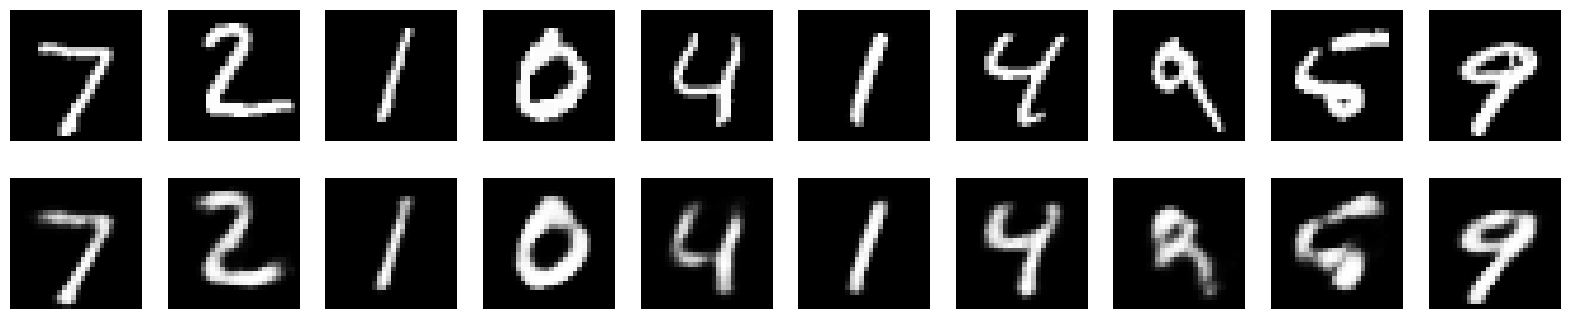

In [ ]:
############
#
# Autoencoders
#
###########
### Import packages
import tensorflow as tf   	# build and train the neural network
from tensorflow.keras import layers  	# create neural network layers
from tensorflow.keras import models 	# define the complete model
import matplotlib.pyplot as plt 	# display images

### Load MNIST dataset
# Loads the MNIST dataset, which contains images of handwritten digits (0–9).
# x_train has training images.
# x_test has testing images.
# _ means we ignore the labels because autoencoders do not need them.

(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

### Normalize pixel values
# Pixel values in images range from 0 to 255.
# Dividing by 255 converts them to 0–1 range.
# Helps the neural network learn better.

x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

### Flatten images (28x28 → 784)
# Each image is 28 × 28 pixels.
# Neural networks often need 1D vectors, so convert:28 × 28 = 784 pixels
# Each image becomes a 784-length vector.

x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

### Encoder
# Input(shape=(784,)) - input layer for 784 pixel values.
# Dense layers gradually reduce the data size:
# 784 to 128
# 128 to 64
# 64 to 32
# The 32-unit layer is called the bottleneck layer, which stores the compressed representation of the image.

input_img = layers.Input(shape=(784,))
encoded = layers.Dense(128, activation='relu')(input_img)
encoded = layers.Dense(64, activation='relu')(encoded)
encoded = layers.Dense(32, activation='relu')(encoded)  # bottleneck layer

### Decoder
# The decoder reconstructs the image by expanding the compressed data:
# 32 to 64
# 64 to 128
# 128 to 784
# The final layer outputs 784 values, which represent the reconstructed image pixels.
# sigmoid ensures output values stay between 0 and 1.

decoded = layers.Dense(64, activation='relu')(encoded)
decoded = layers.Dense(128, activation='relu')(decoded)
decoded = layers.Dense(784, activation='sigmoid')(decoded)

### Autoencoder model
# connects the encoder and decoder into one complete model.
# Input → Encoder → Compressed Representation → Decoder → Reconstructed Image.

autoencoder = models.Model(input_img, decoded)

### Compile model
# optimizer = adam - adjusts weights to improve learning.
# loss = binary_crossentropy - measures how close reconstructed images are to original images.

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

### Train model

# The model learns by comparing input images with their own outputs.
# epochs=10 - training repeats 10 times.
# batch_size=256 - processes 256 images at a time.
# shuffle=True - randomizes training data.
# Validation checks performance using test data.


history = autoencoder.fit(
    x_train, x_train,
    epochs=10,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

### Reconstruct images
# The trained model tries to recreate the test images.

decoded_imgs = autoencoder.predict(x_test)

### Plot original vs reconstructed images
# Original Images
# Reconstructed Images (from compressed data)
# If the model trained well, the reconstructed images will look very similar to the originals.

n = 10
plt.figure(figsize=(20, 4))

for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    plt.axis("off")

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    plt.axis("off")

plt.show()